# TechPulse Evaluation Results Analysis

Loads `eval_summary.json` and `raw_results.json`, generates publication-quality figures,
and exports them to `evaluation/results/figures/`.

**Run after** `python -m evaluation.run_eval` completes all 9 phases.

In [1]:
import json
import math
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

RESULTS_DIR = Path("results")
FIGURES_DIR = RESULTS_DIR / "figures"
TABLES_DIR  = RESULTS_DIR / "tables"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

with open(RESULTS_DIR / "eval_summary.json", encoding="utf-8") as f:
    summary = json.load(f)

with open(RESULTS_DIR / "raw_results.json", encoding="utf-8") as f:
    raw = json.load(f)

# Load RAGAS scores if available
ragas_path = RESULTS_DIR / "ragas_scores.json"
ragas_scores = None
if ragas_path.exists():
    with open(ragas_path, encoding="utf-8") as f:
        ragas_scores = json.load(f)

# Also check summary for ragas key
if ragas_scores is None and "ragas" in summary:
    ragas_scores = summary["ragas"]

print(f"Summary keys: {list(summary.keys())}")
print(f"Raw: {len(raw.get('baseline', []))} baseline, {len(raw.get('hybrid', []))} hybrid")
print(f"RAGAS scores: {'loaded' if ragas_scores else 'not available'}")

Summary keys: ['baseline', 'hybrid', 'delta', 'ragas', 'grid_search', 'sensitivity_analysis', 'statistical_tests', 'drift_validation', 'composite_metric', 'cost_projection']
Raw: 50 baseline, 50 hybrid
RAGAS scores: loaded


## 1. Baseline vs Hybrid — Core Metrics Comparison

Grouped bar chart (maps to `fig:viz_comparison` in the report).

Saved: comparison_bar.png / .pdf


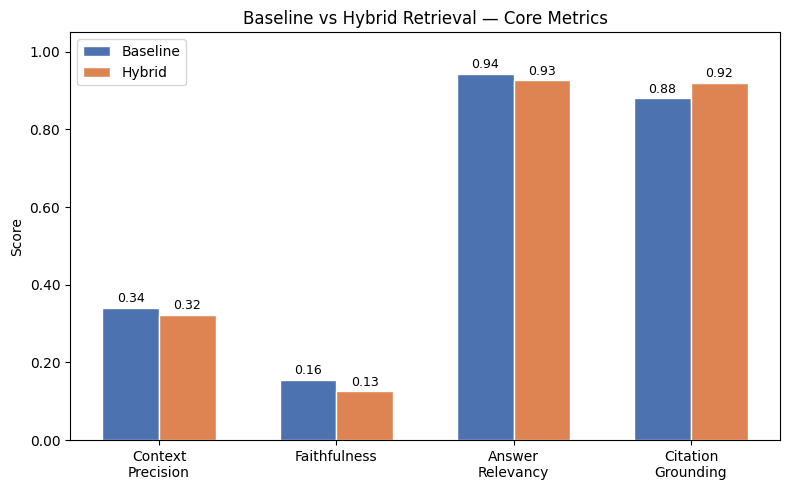

In [2]:
# ---- Figure 1: Grouped bar chart — Baseline vs Hybrid ----
metrics = []
baseline_vals = []
hybrid_vals = []

if ragas_scores:
    n = len(ragas_scores.get("faithfulness", [])) // 2
    for m_key, m_label in [
        ("context_precision", "Context\nPrecision"),
        ("faithfulness", "Faithfulness"),
        ("answer_relevancy", "Answer\nRelevancy"),
    ]:
        vals = ragas_scores.get(m_key, [])
        # First half = baseline, second half = hybrid
        b_vals = [v for v in vals[:n] if not (isinstance(v, float) and math.isnan(v))]
        h_vals = [v for v in vals[n:] if not (isinstance(v, float) and math.isnan(v))]
        metrics.append(m_label)
        baseline_vals.append(np.mean(b_vals) if b_vals else 0)
        hybrid_vals.append(np.mean(h_vals) if h_vals else 0)

# Citation grounding (always available)
metrics.append("Citation\nGrounding")
baseline_vals.append(summary["baseline"]["mean_citation_grounding"])
hybrid_vals.append(summary["hybrid"]["mean_citation_grounding"])

x = np.arange(len(metrics))
width = 0.32

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline", color="#4C72B0", edgecolor="white")
bars2 = ax.bar(x + width/2, hybrid_vals,   width, label="Hybrid",   color="#DD8452", edgecolor="white")

ax.set_ylabel("Score")
ax.set_title("Baseline vs Hybrid Retrieval — Core Metrics")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))

for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f"{h:.2f}", xy=(bar.get_x() + bar.get_width()/2, h),
                    xytext=(0, 4), textcoords="offset points", ha="center", fontsize=9)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "comparison_bar.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "comparison_bar.pdf", bbox_inches="tight")
print("Saved: comparison_bar.png / .pdf")
plt.show()

## 2. Grid Search — Precision vs Latency Pareto

Dual-axis scatter (maps to `fig:viz_pareto` in the report).

Saved: grid_search_pareto.png / .pdf


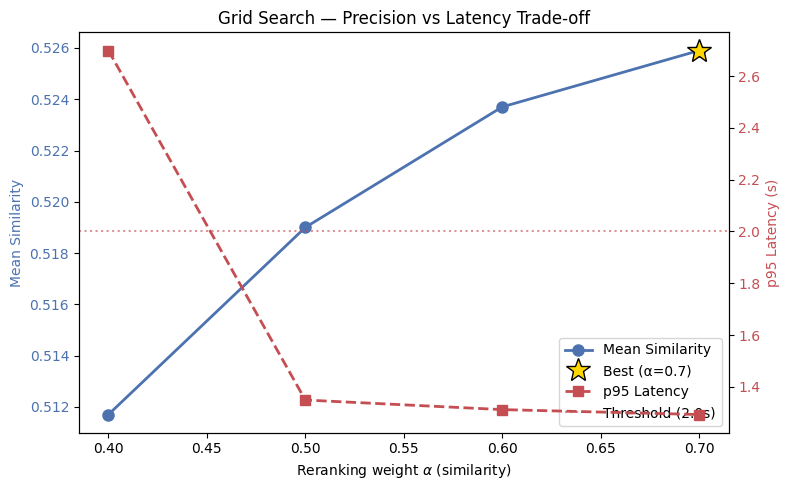

In [3]:
# ---- Figure 2: Grid Search Pareto — Precision vs Latency ----
grid = summary.get("grid_search", {})
configs = grid.get("all_configs", [])
best = grid.get("best", {})
threshold = grid.get("p95_threshold_s", 2.0)

if configs:
    alphas   = [c["alpha"] for c in configs]
    sims     = [c["mean_similarity"] for c in configs]
    p95_lats = [c["p95_latency_s"] for c in configs]

    fig, ax1 = plt.subplots(figsize=(8, 5))
    color1, color2 = "#4C72B0", "#C44E52"

    ax1.plot(alphas, sims, "o-", color=color1, linewidth=2, markersize=8, label="Mean Similarity")
    ax1.set_xlabel(r"Reranking weight $\alpha$ (similarity)")
    ax1.set_ylabel("Mean Similarity", color=color1)
    ax1.tick_params(axis="y", labelcolor=color1)

    # Highlight best
    if best:
        ax1.plot(best["alpha"], best["mean_similarity"], "*", color="gold",
                 markersize=18, zorder=5, markeredgecolor="black", label=f"Best (α={best['alpha']})")

    ax2 = ax1.twinx()
    ax2.plot(alphas, p95_lats, "s--", color=color2, linewidth=2, markersize=7, label="p95 Latency")
    ax2.axhline(y=threshold, color=color2, linestyle=":", alpha=0.6, label=f"Threshold ({threshold}s)")
    ax2.set_ylabel("p95 Latency (s)", color=color2)
    ax2.tick_params(axis="y", labelcolor=color2)

    ax1.set_title("Grid Search — Precision vs Latency Trade-off")
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower right")

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "grid_search_pareto.png", dpi=150, bbox_inches="tight")
    fig.savefig(FIGURES_DIR / "grid_search_pareto.pdf", bbox_inches="tight")
    print("Saved: grid_search_pareto.png / .pdf")
    plt.show()
else:
    print("No grid search data available yet.")

## 3. Source Distribution — Baseline vs Hybrid

Stacked bar chart (maps to `fig:viz_sources` in the report).

Saved: source_distribution.png / .pdf


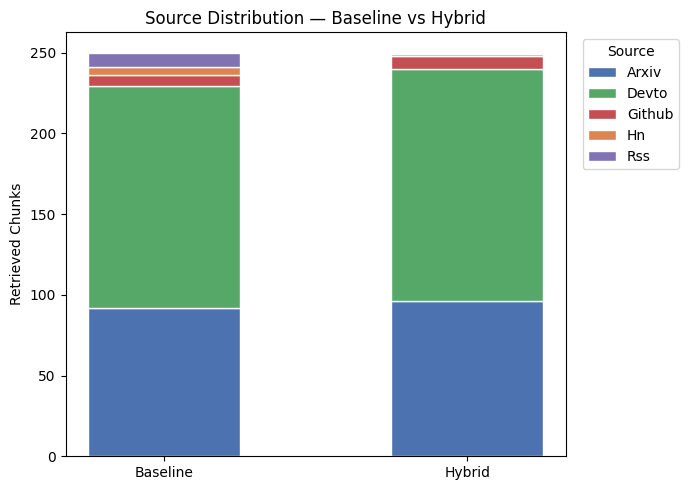

In [4]:
# ---- Figure 3: Source distribution stacked bar ----
from collections import Counter

source_counts = {}
for mode in ("baseline", "hybrid"):
    counter = Counter()
    for entry in raw.get(mode, []):
        for src in entry.get("sources", []):
            counter[src.get("source", "unknown")] += 1
    source_counts[mode] = counter

all_sources = sorted(set(source_counts["baseline"].keys()) | set(source_counts["hybrid"].keys()))
colors_map = {"arxiv": "#4C72B0", "hn": "#DD8452", "devto": "#55A868",
              "github": "#C44E52", "rss": "#8172B3", "unknown": "#999999"}

fig, ax = plt.subplots(figsize=(7, 5))
modes = ["Baseline", "Hybrid"]
x = np.arange(len(modes))
bottoms = np.zeros(len(modes))

for src in all_sources:
    vals = [source_counts["baseline"].get(src, 0), source_counts["hybrid"].get(src, 0)]
    ax.bar(x, vals, 0.5, bottom=bottoms, label=src.title(),
           color=colors_map.get(src, "#AAAAAA"), edgecolor="white")
    bottoms += vals

ax.set_ylabel("Retrieved Chunks")
ax.set_title("Source Distribution — Baseline vs Hybrid")
ax.set_xticks(x)
ax.set_xticklabels(modes)
ax.legend(title="Source", bbox_to_anchor=(1.02, 1), loc="upper left")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "source_distribution.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "source_distribution.pdf", bbox_inches="tight")
print("Saved: source_distribution.png / .pdf")
plt.show()

## 4. Latency Breakdown by Category

Horizontal grouped bar (maps to `fig:viz_latency` in the report).

Saved: latency_by_category.png / .pdf


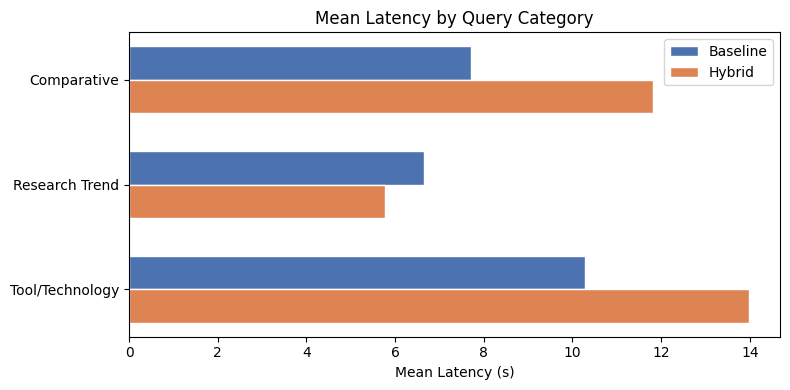

In [5]:
# ---- Figure 4: Latency by category — horizontal grouped bar ----
categories = ["comparative", "research_trend", "tool_technology"]
cat_labels  = ["Comparative", "Research Trend", "Tool/Technology"]

b_means = [summary["baseline"].get(f"mean_latency_{c}", 0) for c in categories]
h_means = [summary["hybrid"].get(f"mean_latency_{c}", 0)   for c in categories]

y = np.arange(len(categories))
height = 0.32

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(y - height/2, b_means, height, label="Baseline", color="#4C72B0", edgecolor="white")
ax.barh(y + height/2, h_means, height, label="Hybrid",   color="#DD8452", edgecolor="white")

ax.set_xlabel("Mean Latency (s)")
ax.set_title("Mean Latency by Query Category")
ax.set_yticks(y)
ax.set_yticklabels(cat_labels)
ax.legend()
ax.invert_yaxis()

fig.tight_layout()
fig.savefig(FIGURES_DIR / "latency_by_category.png", dpi=150, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "latency_by_category.pdf", bbox_inches="tight")
print("Saved: latency_by_category.png / .pdf")
plt.show()

## 5. RAGAS Score Distributions (Box Plots)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_34372\3710707660.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([b_vals, h_vals], labels=["Baseline", "Hybrid"],
C:\Users\ASUS\AppData\Local\Temp\ipykernel_34372\3710707660.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([b_vals, h_vals], labels=["Baseline", "Hybrid"],
C:\Users\ASUS\AppData\Local\Temp\ipykernel_34372\3710707660.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([b_vals, h_vals], labels=["Baseline", "Hybrid"],


Saved: ragas_boxplots.png / .pdf


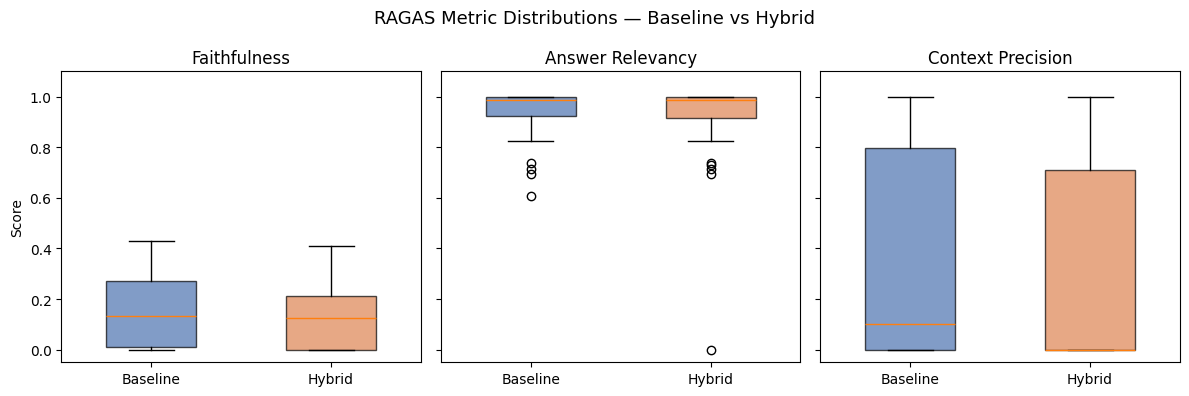

In [6]:
# ---- Figure 5: RAGAS score distributions ----
if ragas_scores:
    n = len(ragas_scores.get("faithfulness", [])) // 2
    ragas_metrics = ["faithfulness", "answer_relevancy", "context_precision"]
    labels = ["Faithfulness", "Answer Relevancy", "Context Precision"]

    fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=True)
    for ax, key, label in zip(axes, ragas_metrics, labels):
        vals = ragas_scores.get(key, [])
        b_vals = [v for v in vals[:n] if not (isinstance(v, float) and math.isnan(v))]
        h_vals = [v for v in vals[n:] if not (isinstance(v, float) and math.isnan(v))]

        bp = ax.boxplot([b_vals, h_vals], labels=["Baseline", "Hybrid"],
                        patch_artist=True, widths=0.5)
        bp["boxes"][0].set_facecolor("#4C72B0")
        bp["boxes"][1].set_facecolor("#DD8452")
        for box in bp["boxes"]:
            box.set_alpha(0.7)
        ax.set_title(label)
        ax.set_ylim(-0.05, 1.1)

    axes[0].set_ylabel("Score")
    fig.suptitle("RAGAS Metric Distributions — Baseline vs Hybrid", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "ragas_boxplots.png", dpi=150, bbox_inches="tight")
    fig.savefig(FIGURES_DIR / "ragas_boxplots.pdf", bbox_inches="tight")
    print("Saved: ragas_boxplots.png / .pdf")
    plt.show()
else:
    print("RAGAS scores not available — skipping box plots.")

## 6. Summary Table (Markdown + CSV export)

In [7]:
# ---- Summary comparison table ----
from IPython.display import Markdown

rows = []
rows.append("| Metric | Baseline | Hybrid | Delta |")
rows.append("|--------|----------|--------|-------|")

b, h, d = summary["baseline"], summary["hybrid"], summary["delta"]

def fmt(v, unit=""):
    if isinstance(v, float):
        return f"{v:.3f}{unit}"
    return str(v)

table_data = [
    ("Queries",              b["num_queries"],           h["num_queries"],           ""),
    ("Mean Latency (s)",     b["mean_latency_s"],        h["mean_latency_s"],        d["latency_diff_s"]),
    ("Median Latency (s)",   b["median_latency_s"],      h["median_latency_s"],      ""),
    ("p95 Latency (s)",      b["p95_latency_s"],         h["p95_latency_s"],         d["p95_latency_diff_s"]),
    ("Citation Grounding",   b["mean_citation_grounding"],h["mean_citation_grounding"],d["citation_grounding_diff"]),
    ("Tokens/Query",         b.get("mean_tokens_per_query",""), h.get("mean_tokens_per_query",""), ""),
    ("Est. Cost (USD)",      b.get("total_estimated_cost_usd",""), h.get("total_estimated_cost_usd",""), ""),
]

# Add RAGAS rows if available
if ragas_scores:
    n = len(ragas_scores.get("faithfulness", [])) // 2
    for key, label in [("faithfulness", "Faithfulness"), ("answer_relevancy", "Answer Relevancy"),
                       ("context_precision", "Context Precision")]:
        vals = ragas_scores.get(key, [])
        b_v = [v for v in vals[:n] if not (isinstance(v, float) and math.isnan(v))]
        h_v = [v for v in vals[n:] if not (isinstance(v, float) and math.isnan(v))]
        bm = np.mean(b_v) if b_v else 0
        hm = np.mean(h_v) if h_v else 0
        table_data.append((label, round(bm, 4), round(hm, 4), round(hm - bm, 4)))

for label, bv, hv, dv in table_data:
    rows.append(f"| {label} | {fmt(bv)} | {fmt(hv)} | {fmt(dv) if dv != '' else ''} |")

md_table = "\n".join(rows)

# Save as markdown
with open(TABLES_DIR / "comparison_table.md", "w", encoding="utf-8") as f:
    f.write(md_table)

# Save as CSV
import csv
with open(TABLES_DIR / "comparison_table.csv", "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["Metric", "Baseline", "Hybrid", "Delta"])
    for label, bv, hv, dv in table_data:
        w.writerow([label, bv, hv, dv])

print("Saved: comparison_table.md / .csv")
display(Markdown(md_table))

Saved: comparison_table.md / .csv


| Metric | Baseline | Hybrid | Delta |
|--------|----------|--------|-------|
| Queries | 50 | 50 |  |
| Mean Latency (s) | 8.156 | 10.332 | 2.176 |
| Median Latency (s) | 6.261 | 12.325 |  |
| p95 Latency (s) | 13.118 | 25.012 | 11.894 |
| Citation Grounding | 0.880 | 0.920 | 0.040 |
| Tokens/Query | 2363.100 | 2502.400 |  |
| Est. Cost (USD) | 0.006 | 0.006 |  |
| Faithfulness | 0.155 | 0.126 | -0.029 |
| Answer Relevancy | 0.943 | 0.927 | -0.016 |
| Context Precision | 0.340 | 0.323 | -0.017 |

## 7. TikZ Coordinate Export

Prints coordinate values ready to paste into the LaTeX report's TikZ charts.

In [8]:
# ---- TikZ coordinates for report charts ----
print("=" * 60)
print("TikZ COORDINATES — paste into report/chapters/ch5_evaluation.tex")
print("=" * 60)

# Fig 1: Comparison bar chart coordinates
if ragas_scores:
    n = len(ragas_scores.get("faithfulness", [])) // 2
    print("\n--- fig:viz_comparison (grouped bar) ---")
    bar_metrics = ["context_precision", "faithfulness", "answer_relevancy"]
    bar_labels  = ["Ctx Prec", "Faith", "Ans Rel"]
    for key, label in zip(bar_metrics, bar_labels):
        vals = ragas_scores.get(key, [])
        b_v = [v for v in vals[:n] if not (isinstance(v, float) and math.isnan(v))]
        h_v = [v for v in vals[n:] if not (isinstance(v, float) and math.isnan(v))]
        bm = np.mean(b_v) if b_v else 0
        hm = np.mean(h_v) if h_v else 0
        print(f"  {label:12s}  Baseline={bm:.4f}  Hybrid={hm:.4f}")
    cg_b = summary["baseline"]["mean_citation_grounding"]
    cg_h = summary["hybrid"]["mean_citation_grounding"]
    print(f"  {'Citation':12s}  Baseline={cg_b:.4f}  Hybrid={cg_h:.4f}")

# Fig 2: Grid search Pareto coordinates
print("\n--- fig:viz_pareto (grid search) ---")
print("  \\addplot coordinates {")
for c in summary.get("grid_search", {}).get("all_configs", []):
    print(f"    ({c['alpha']}, {c['mean_similarity']})")
print("  };")
print("  \\addplot[yshift] coordinates {")
for c in summary.get("grid_search", {}).get("all_configs", []):
    print(f"    ({c['alpha']}, {c['p95_latency_s']})")
print("  };")

# Fig 4: Latency by category
print("\n--- fig:viz_latency (latency by category) ---")
for cat in ["comparative", "research_trend", "tool_technology"]:
    bm = summary["baseline"].get(f"mean_latency_{cat}", 0)
    hm = summary["hybrid"].get(f"mean_latency_{cat}", 0)
    print(f"  {cat:20s}  Baseline={bm:.3f}s  Hybrid={hm:.3f}s")

print("\n" + "=" * 60)

TikZ COORDINATES — paste into report/chapters/ch5_evaluation.tex

--- fig:viz_comparison (grouped bar) ---
  Ctx Prec      Baseline=0.3400  Hybrid=0.3230
  Faith         Baseline=0.1555  Hybrid=0.1262
  Ans Rel       Baseline=0.9428  Hybrid=0.9270
  Citation      Baseline=0.8800  Hybrid=0.9200

--- fig:viz_pareto (grid search) ---
  \addplot coordinates {
    (0.4, 0.5117)
    (0.5, 0.519)
    (0.6, 0.5237)
    (0.7, 0.5259)
  };
  \addplot[yshift] coordinates {
    (0.4, 2.699)
    (0.5, 1.349)
    (0.6, 1.312)
    (0.7, 1.293)
  };

--- fig:viz_latency (latency by category) ---
  comparative           Baseline=7.711s  Hybrid=11.808s
  research_trend        Baseline=6.659s  Hybrid=5.777s
  tool_technology       Baseline=10.284s  Hybrid=13.981s



## 8. Statistical Tests & Composite Score

In [9]:
# ---- Statistical tests summary ----
if "statistical_tests" in summary:
    st = summary["statistical_tests"]
    print("Statistical Tests:")
    for test_name, result in st.items():
        if isinstance(result, dict):
            sig = result.get("significant", "")
            p = result.get("p_value", result.get("p", ""))
            print(f"  {test_name}: p={p}, significant={sig}")
        else:
            print(f"  {test_name}: {result}")
else:
    print("Statistical tests not available yet.")

print()

if "composite_metric" in summary:
    cm = summary["composite_metric"]
    print(f"Composite Score: {cm}")
else:
    print("Composite metric not available yet.")

Statistical Tests:
  n_pairs: 50
  latency_wilcoxon: p=0.011867, significant=
  latency_cohens_d: -0.2811
  effect_size: small
  citation_wilcoxon: p=0.414216, significant=
  precision_wilcoxon: p=0.905742, significant=
  latency_diff_95ci: [-4.293, 0.063]

Composite Score: {'baseline': {'composite_score': 0.5341, 'components': {'citation_grounding': 0.88, 'faithfulness': 0.1555, 'answer_relevancy': 0.9428, 'context_precision': 0.34}, 'weights': {'faithfulness': 0.35, 'answer_relevancy': 0.25, 'context_precision': 0.2, 'citation_grounding': 0.2}}, 'hybrid': {'composite_score': 0.5245, 'components': {'citation_grounding': 0.92, 'faithfulness': 0.1262, 'answer_relevancy': 0.927, 'context_precision': 0.323}, 'weights': {'faithfulness': 0.35, 'answer_relevancy': 0.25, 'context_precision': 0.2, 'citation_grounding': 0.2}}, 'composite_diff': -0.0096}


## 9. Cost Projection

In [10]:
# ---- Cost projection ----
if "cost_projection" in summary:
    cp = summary["cost_projection"]
    print("Monthly Cost Projections:")
    print(json.dumps(cp, indent=2))
else:
    print("Cost projection not available yet.")

Monthly Cost Projections:
{
  "baseline": {
    "tokens_per_query": 2363.1,
    "cost_per_query_usd": 0.0001108,
    "scenarios": {
      "50_queries_per_day": {
        "monthly_queries": 1500,
        "monthly_tokens": 3544650,
        "monthly_cost_usd": 0.1662,
        "fits_groq_free_tier": true
      },
      "100_queries_per_day": {
        "monthly_queries": 3000,
        "monthly_tokens": 7089300,
        "monthly_cost_usd": 0.3324,
        "fits_groq_free_tier": true
      },
      "200_queries_per_day": {
        "monthly_queries": 6000,
        "monthly_tokens": 14178600,
        "monthly_cost_usd": 0.6648,
        "fits_groq_free_tier": true
      }
    }
  },
  "hybrid": {
    "tokens_per_query": 2502.4,
    "cost_per_query_usd": 0.0001162,
    "scenarios": {
      "50_queries_per_day": {
        "monthly_queries": 1500,
        "monthly_tokens": 3753600,
        "monthly_cost_usd": 0.1743,
        "fits_groq_free_tier": true
      },
      "100_queries_per_day": {
      

## 10. Sensitivity Analysis — Reranking Weight Sweep

Line plots showing how varying each reranking parameter (α, β, γ) individually affects
mean similarity, while holding the others proportional to the grid-search optimum.

Saved: sensitivity_analysis.png / .pdf


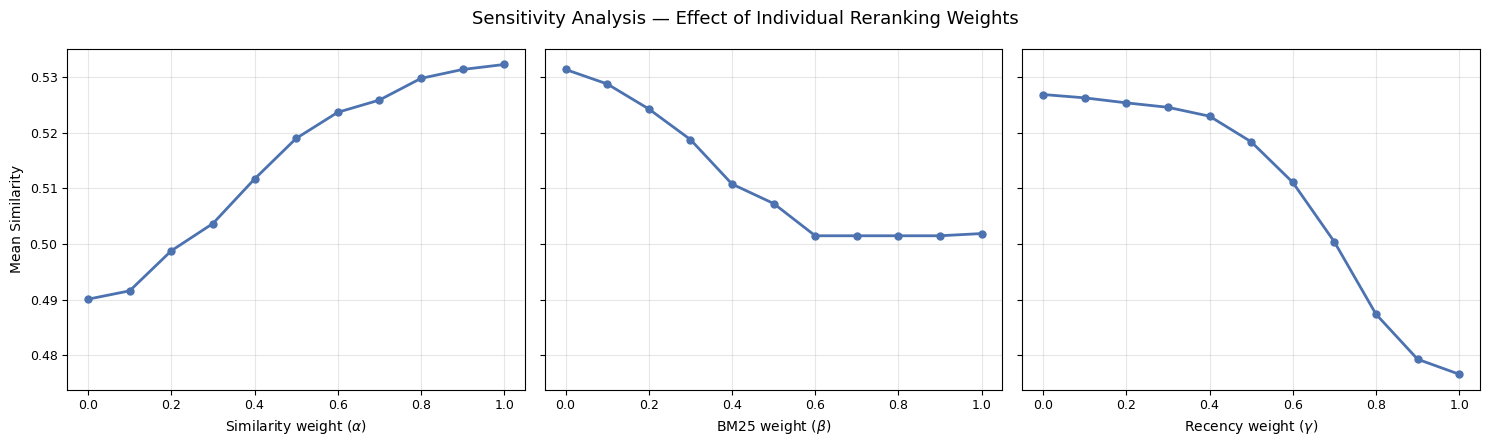

In [11]:
# ---- Figure 6: Sensitivity analysis ----
sens = summary.get("sensitivity_analysis", {})
if sens:
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)
    param_labels = {
        "alpha": r"Similarity weight ($\alpha$)",
        "beta":  r"BM25 weight ($\beta$)",
        "gamma": r"Recency weight ($\gamma$)",
    }

    for ax, param in zip(axes, ["alpha", "beta", "gamma"]):
        data = sens.get(param, [])
        xs = [d["param_value"] for d in data]
        sims = [d["mean_similarity"] for d in data]

        ax.plot(xs, sims, "o-", color="#4C72B0", linewidth=2, markersize=5)
        ax.set_xlabel(param_labels[param], fontsize=10)
        ax.set_xlim(-0.05, 1.05)
        ax.grid(True, alpha=0.3)
        ax.tick_params(labelsize=9)

    axes[0].set_ylabel("Mean Similarity", fontsize=10)
    fig.suptitle("Sensitivity Analysis — Effect of Individual Reranking Weights", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "sensitivity_analysis.png", dpi=150, bbox_inches="tight")
    fig.savefig(FIGURES_DIR / "sensitivity_analysis.pdf", bbox_inches="tight")
    print("Saved: sensitivity_analysis.png / .pdf")
    plt.show()
else:
    print("Sensitivity analysis data not available.")

## 11. Latency Cumulative Distribution Function (CDF)

Shows the probability of completing a query within a given latency, highlighting
tail behaviour (p95, p99) for both retrieval modes.

Saved: latency_cdf.png / .pdf


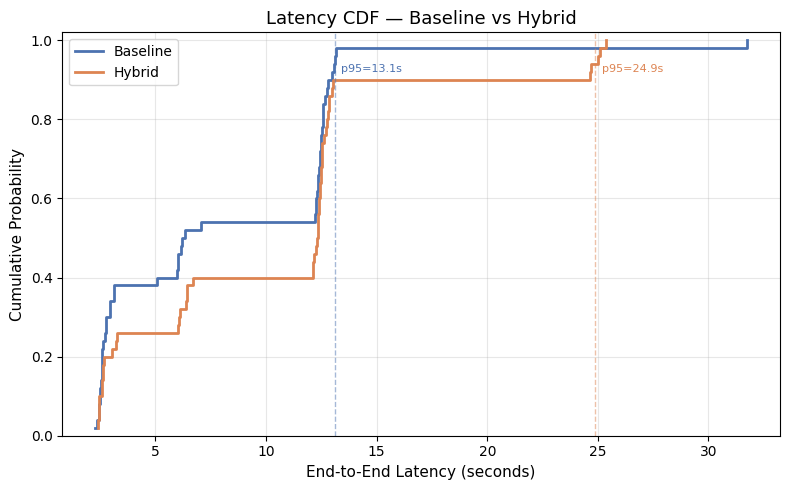

In [12]:
# ---- Figure 7: Latency CDF ----
b_lats = [r["latency_s"] for r in raw.get("baseline", []) if "latency_s" in r]
h_lats = [r["latency_s"] for r in raw.get("hybrid", []) if "latency_s" in r]

if b_lats and h_lats:
    fig, ax = plt.subplots(figsize=(8, 5))

    for lats, label, color in [(b_lats, "Baseline", "#4C72B0"),
                                (h_lats, "Hybrid", "#DD8452")]:
        sorted_lats = np.sort(lats)
        cdf = np.arange(1, len(sorted_lats) + 1) / len(sorted_lats)
        ax.step(sorted_lats, cdf, where="post", label=label, color=color, linewidth=2)

    # Mark p95 lines
    for lats, color, label in [(b_lats, "#4C72B0", "Baseline p95"),
                                (h_lats, "#DD8452", "Hybrid p95")]:
        p95 = np.percentile(lats, 95)
        ax.axvline(p95, color=color, linestyle="--", alpha=0.5, linewidth=1)
        ax.annotate(f"p95={p95:.1f}s", xy=(p95, 0.95), fontsize=8,
                    color=color, ha="left", va="bottom",
                    xytext=(5, -10), textcoords="offset points")

    ax.set_xlabel("End-to-End Latency (seconds)", fontsize=11)
    ax.set_ylabel("Cumulative Probability", fontsize=11)
    ax.set_title("Latency CDF — Baseline vs Hybrid", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0, 1.02)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "latency_cdf.png", dpi=150, bbox_inches="tight")
    fig.savefig(FIGURES_DIR / "latency_cdf.pdf", bbox_inches="tight")
    print("Saved: latency_cdf.png / .pdf")
    plt.show()
else:
    print("Raw latency data not available.")

## 12. Per-Query Latency vs Citation Grounding (Scatter)

Scatter plot showing the trade-off between response quality (citation grounding)
and latency for each individual query, coloured by retrieval mode.

Saved: per_query_scatter.png / .pdf


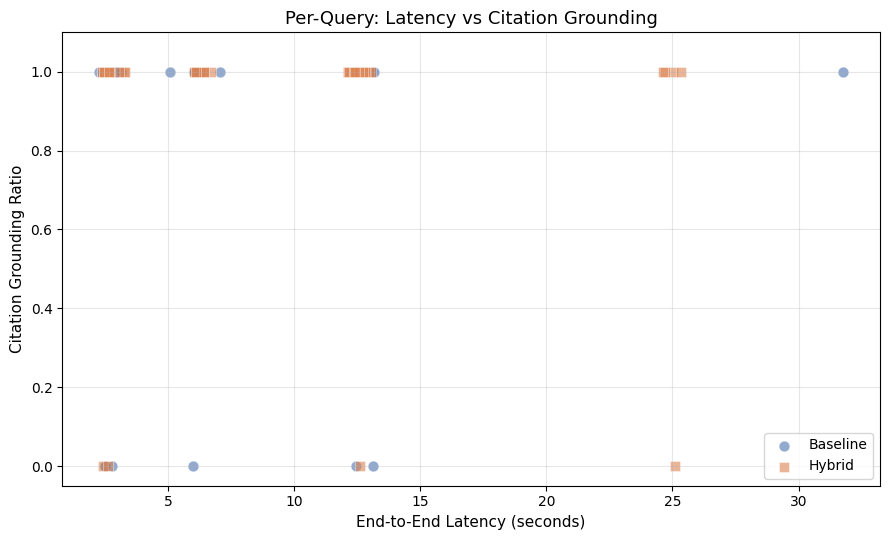

In [14]:
# ---- Figure 8: Per-query scatter ----
b_data = raw.get("baseline", [])
h_data = raw.get("hybrid", [])

if b_data and h_data:
    fig, ax = plt.subplots(figsize=(9, 5.5))

    for data, label, color, marker in [(b_data, "Baseline", "#4C72B0", "o"),
                                        (h_data, "Hybrid", "#DD8452", "s")]:
        lats = [r["latency_s"] for r in data if "latency_s" in r and "citation_grounding" in r]
        cites = [r["citation_grounding"] for r in data if "latency_s" in r and "citation_grounding" in r]
        ax.scatter(lats, cites, label=label, color=color, marker=marker,
                   alpha=0.6, edgecolors="white", linewidth=0.5, s=60)

    ax.set_xlabel("End-to-End Latency (seconds)", fontsize=11)
    ax.set_ylabel("Citation Grounding Ratio", fontsize=11)
    ax.set_title("Per-Query: Latency vs Citation Grounding", fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.1)

    fig.tight_layout()
    fig.savefig(FIGURES_DIR / "per_query_scatter.png", dpi=150, bbox_inches="tight")
    fig.savefig(FIGURES_DIR / "per_query_scatter.pdf", bbox_inches="tight")
    print("Saved: per_query_scatter.png / .pdf")
    plt.show()
else:
    print("Raw data not available for scatter plot.")

---

### Output Locations

| Type | Path |
|------|------|
| Figures (PNG + PDF) | `evaluation/results/figures/` |
| Tables (MD + CSV) | `evaluation/results/tables/` |
| Raw JSON | `evaluation/results/raw_results.json` |
| Summary JSON | `evaluation/results/eval_summary.json` |
| RAGAS Scores | `evaluation/results/ragas_scores.json` |